<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn wfdb pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("heart.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    0   0       129   188    0        0       97      0      3.7      0   
1   43    0   1       177   305    1        0      185      1      5.0      0   
2   50    1   1       121   321    1        0       94      1      0.6      1   
3   63    0   3       104   267    1        2      163      0      4.4      0   
4   43    0   3       129   242    1        0      165      1      1.3      1   

   ca  thal  target  
0   0     3       0  
1   1     7       1  
2   2     3       1  
3   1     6       0  
4   0     7       0  


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(50, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       50 non-null     int64  
 1   sex       50 non-null     int64  
 2   cp        50 non-null     int64  
 3   trestbps  50 non-null     int64  
 4   chol      50 non-null     int64  
 5   fbs       50 non-null     int64  
 6   restecg   50 non-null     int64  
 7   thalach   50 non-null     int64  
 8   exang     50 non-null     int64  
 9   oldpeak   50 non-null     float64
 10  slope     50 non-null     int64  
 11  ca        50 non-null     int64  
 12  thal      50 non-null     int64  
 13  target    50 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 5.6 KB
No

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


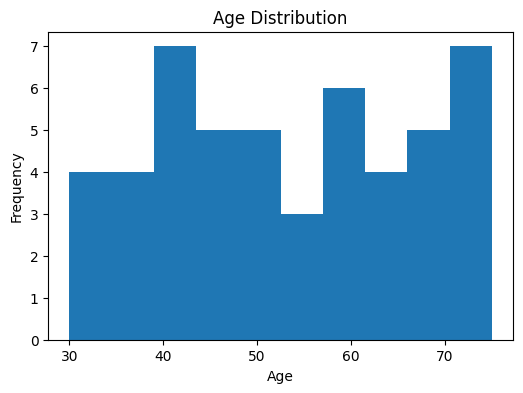

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
y = y.apply(lambda x: 1 if x > 0 else 0)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.3


Confusion Matrix:
[[1 4]
 [3 2]]


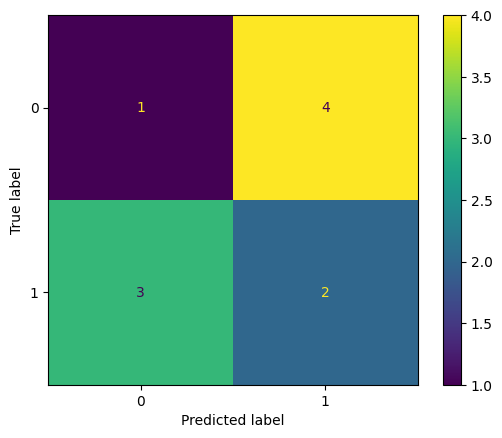

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot()

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

probability = model.predict_proba(X_test)[:, 1]

roc_score = roc_auc_score(y_test, probability)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.28


In [ ]:
!pip install wfdb

In [ ]:
import wfdb
import matplotlib.pyplot as plt

In [ ]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

signal = record.p_signal

print("Signal Shape:")
print(signal.shape)

print("Sampling Frequency:")
print(record.fs)

Signal Shape:
(650000, 2)
Sampling Frequency:
360


In [ ]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("First 10 annotations:")
print(annotation.symbol[:10])

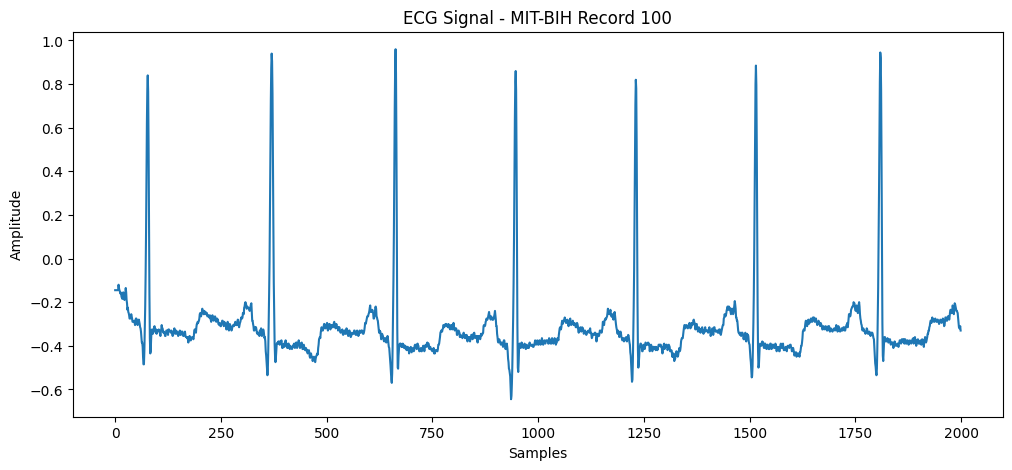

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(signal[:2000, 0])

plt.title("ECG Signal - MIT-BIH Record 100")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
text = """
Patient is experiencing chest pain and shortness of breath.
The patient has high blood pressure and high cholesterol.
Doctor recommended further cardiac examination.
"""

print(text)


Patient is experiencing chest pain and shortness of breath.
The patient has high blood pressure and high cholesterol.
Doctor recommended further cardiac examination.



In [ ]:
text = """
Patient is experiencing chest pain and shortness of breath.
The patient has high blood pressure and high cholesterol.
Doctor recommended further cardiac examination.
"""

print(text)


Patient is experiencing chest pain and shortness of breath.
The patient has high blood pressure and high cholesterol.
Doctor recommended further cardiac examination.



In [ ]:
import re

# Convert text to lowercase
text = text.lower()

# Remove special characters
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Tokenization
tokens = text.split()

print("Tokens:")
print(tokens)

Tokens:
['patient', 'is', 'experiencing', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'has', 'high', 'blood', 'pressure', 'and', 'high', 'cholesterol', 'doctor', 'recommended', 'further', 'cardiac', 'examination']


In [ ]:
from collections import Counter

word_frequency = Counter(tokens)

print("Word Frequency:")

for word, count in word_frequency.items():
    print(word, ":", count)

Word Frequency:
patient : 2
is : 1
experiencing : 1
chest : 1
pain : 1
and : 2
shortness : 1
of : 1
breath : 1
the : 1
has : 1
high : 2
blood : 1
pressure : 1
cholesterol : 1
doctor : 1
recommended : 1
further : 1
cardiac : 1
examination : 1


In [ ]:
medical_terms = [
    "chest",
    "pain",
    "breath",
    "blood",
    "pressure",
    "cholesterol",
    "cardiac"
]

found_terms = []

for word in medical_terms:
    if word in tokens:
        found_terms.append(word)

print("Medical Terms Found:")
print(found_terms)

Medical Terms Found:
['chest', 'pain', 'breath', 'blood', 'pressure', 'cholesterol', 'cardiac']


Image Format: PNG
Image Size: (1448, 1086)
Image Mode: RGB


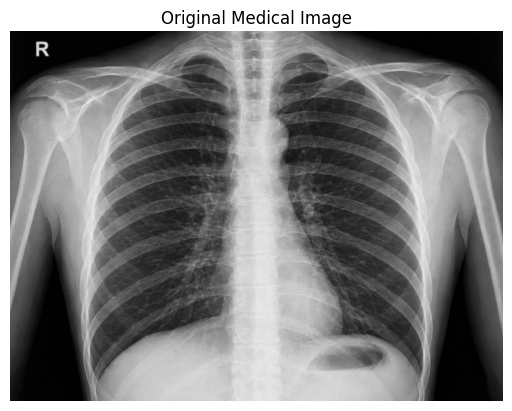

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("xray.png")

print("Image Format:", image.format)
print("Image Size:", image.size)
print("Image Mode:", image.mode)

plt.imshow(image)

plt.title("Original Medical Image")

plt.axis("off")

plt.show()

New Image Size:
(256, 256)


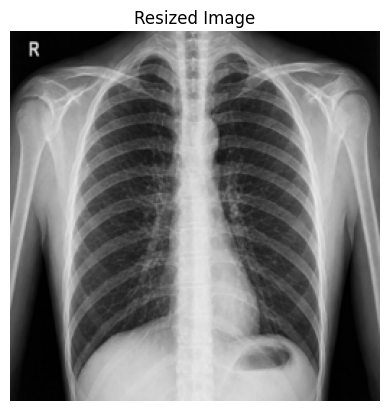

In [ ]:
resized_image = image.resize((256, 256))

print("New Image Size:")
print(resized_image.size)

plt.imshow(resized_image)

plt.title("Resized Image")

plt.axis("off")

plt.show()

In [ ]:
image_array = np.array(resized_image)

normalized_image = image_array / 255.0

print("Minimum Pixel Value:", normalized_image.min())

print("Maximum Pixel Value:", normalized_image.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 0.9215686274509803


In [ ]:
print("""
MULTIMODAL HEALTHCARE DATA INTEGRATION

Tabular Data:
Age, blood pressure, cholesterol

Signal Data:
ECG features and heart rate

Text Data:
Patient symptoms and clinical notes

Image Data:
X-ray or other medical images

These different data types can be combined in the future
to build a multimodal healthcare prediction system.
""")


MULTIMODAL HEALTHCARE DATA INTEGRATION

Tabular Data:
Age, blood pressure, cholesterol

Signal Data:
ECG features and heart rate

Text Data:
Patient symptoms and clinical notes

Image Data:
X-ray or other medical images

These different data types can be combined in the future
to build a multimodal healthcare prediction system.

